# 03. Обучение модели прогнозирования ERR

Таргет: `log_ERR` = log(1 + ERR). Метрики: R², MAE, RMSE. Data leakage исключён.

## 0. Импорты

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, itertools
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
RND = 42
print('OK')

OK


## 1. Загрузка model_ready.csv

In [10]:
df = pd.read_csv("../data/processed/model_ready.csv")
# Подгружаем даты через джойн по ключу
raw = pd.read_csv("../data/raw/all_posts_raw.csv")
raw = raw[raw["views_count"] > 0]
raw["key"] = raw["platform"] + "_" + raw["channel_username"].astype(str) + "_" + raw["post_id"].astype(str)
if "platform" in df.columns and "post_id" in df.columns:
    df["key"] = df["platform"] + "_" + df["channel_username"].astype(str) + "_" + df["post_id"].astype(str)
    dates_map = raw[["key", "published_at"]].drop_duplicates("key")
    df = df.merge(dates_map, on="key", how="left")
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
    df.drop(columns=["key"], inplace=True)
    print(f"Даты загружены: {df["published_at"].notna().sum()}/{len(df)}")
else:
    print("platform/post_id не найдены — пересоздай model_ready.csv через 02 ноутбук")

print(f"{len(df)} постов, {len(df.columns)} колонок")

TARGET, TARGET_RAW = "log_ERR", "ERR"
EXCLUDE = [TARGET, TARGET_RAW, "country", "city", "platform", "channel_username", "post_id", "published_at", "key"]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

CAT_FEATURES = ["hour","day_of_week","month","is_weekend","is_advert","is_telegram",
                "has_photo","has_video","has_document","has_link","has_hashtag","has_any_media"]

print(f"{len(FEATURES)} признаков, {len(CAT_FEATURES)} категориальных")
print(f"Target: {TARGET} (mean={df[TARGET].mean():.3f}, std={df[TARGET].std():.3f})")
print(f"ERR: mean={df[TARGET_RAW].mean():.2f}%, median={df[TARGET_RAW].median():.2f}%")


Даты загружены: 67410/67410
67410 постов, 35 колонок
27 признаков, 12 категориальных
Target: log_ERR (mean=0.409, std=0.609)
ERR: mean=1.44%, median=0.24%


In [11]:
df = df.dropna(subset=[TARGET, TARGET_RAW]).copy()
X = df[FEATURES].copy()
y_log, y_raw = df[TARGET].copy(), df[TARGET_RAW].copy()
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RND)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 53928, Test: 13482


## 2. Baseline

In [12]:
results = []
def evaluate(name, y_true_log, y_pred_log):
    y_true_raw, y_pred_raw = np.expm1(y_true_log), np.expm1(y_pred_log)
    return {'Model':name,'R2':r2_score(y_true_log,y_pred_log),'MAE_log':mean_absolute_error(y_true_log,y_pred_log),
            'RMSE_log':np.sqrt(mean_squared_error(y_true_log,y_pred_log)),
            'MAE_ERR%':mean_absolute_error(y_true_raw,y_pred_raw),'RMSE_ERR%':np.sqrt(mean_squared_error(y_true_raw,y_pred_raw))}

results.append(evaluate('Mean Baseline', y_test_log, np.full_like(y_test_log, y_train_log.mean())))
lr = LinearRegression(); lr.fit(X_train, y_train_log)
results.append(evaluate('LinearRegression', y_test_log, lr.predict(X_test)))
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RND, n_jobs=-1)
rf.fit(X_train, y_train_log)
results.append(evaluate('RandomForest', y_test_log, rf.predict(X_test)))
pd.DataFrame(results).set_index('Model').round(4)

,R2,MAE_log,RMSE_log,MAE_ERR%,RMSE_ERR%
Model,,,,,
Mean Baseline,-0.0000,0.3675,0.6041,1.3906,7.3735
LinearRegression,0.5646,0.2669,0.3986,1.4676,11.7758
RandomForest,0.8159,0.1690,0.2592,0.6354,3.3580


## 3. CatBoost (базовый)

In [13]:
cat_f = [c for c in CAT_FEATURES if c in X.columns]
cb_base = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cat_f, random_seed=RND, verbose=100)
cb_base.fit(X_train, y_train_log)
results.append(evaluate('CatBoost (base)', y_test_log, cb_base.predict(X_test)))
pd.DataFrame(results).set_index('Model').round(4)

0:	learn: 0.5889299	total: 158ms	remaining: 1m 18s
100:	learn: 0.2746462	total: 14.6s	remaining: 57.8s
200:	learn: 0.2660407	total: 29.1s	remaining: 43.3s
300:	learn: 0.2616715	total: 42.1s	remaining: 27.8s
400:	learn: 0.2586481	total: 54.9s	remaining: 13.6s
499:	learn: 0.2560542	total: 1m 8s	remaining: 0us


,R2,MAE_log,RMSE_log,MAE_ERR%,RMSE_ERR%
Model,,,,,
Mean Baseline,-0.0000,0.3675,0.6041,1.3906,7.3735
LinearRegression,0.5646,0.2669,0.3986,1.4676,11.7758
RandomForest,0.8159,0.1690,0.2592,0.6354,3.3580
CatBoost (base),0.8082,0.1726,0.2646,0.6709,3.5207


## 4. Подбор гиперпараметров CatBoost

In [14]:
# Лучшие параметры с прошлого перебора
best_params = {"learning_rate": 0.1, "depth": 8, "l2_leaf_reg": 1, "iterations": 700}
print(f"Параметры: {best_params}")


Параметры: {'learning_rate': 0.1, 'depth': 8, 'l2_leaf_reg': 1, 'iterations': 700}


In [15]:
cb_final = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=8,
    l2_leaf_reg=1, random_strength=0.5,
    bagging_temperature=0.3,
    cat_features=cat_f, random_seed=RND,
    early_stopping_rounds=30,
    verbose=100
)
cb_final.fit(X_train, y_train_log)
y_pred_cb = cb_final.predict(X_test)
results.append(evaluate("CatBoost (tuned)", y_test_log, y_pred_cb))
pd.DataFrame(results).set_index("Model").round(4)


0:	learn: 0.5655034	total: 213ms	remaining: 3m 32s
100:	learn: 0.2544002	total: 19.9s	remaining: 2m 57s
200:	learn: 0.2436575	total: 39.1s	remaining: 2m 35s
300:	learn: 0.2351857	total: 59.1s	remaining: 2m 17s
400:	learn: 0.2277925	total: 1m 20s	remaining: 2m
500:	learn: 0.2219692	total: 1m 41s	remaining: 1m 41s
600:	learn: 0.2172258	total: 2m 2s	remaining: 1m 21s
700:	learn: 0.2124710	total: 2m 21s	remaining: 1m
800:	learn: 0.2083869	total: 2m 40s	remaining: 39.9s
900:	learn: 0.2046706	total: 3m 1s	remaining: 19.9s
999:	learn: 0.2009081	total: 3m 18s	remaining: 0us


,R2,MAE_log,RMSE_log,MAE_ERR%,RMSE_ERR%
Model,,,,,
Mean Baseline,-0.0000,0.3675,0.6041,1.3906,7.3735
LinearRegression,0.5646,0.2669,0.3986,1.4676,11.7758
RandomForest,0.8159,0.1690,0.2592,0.6354,3.3580
CatBoost (base),0.8082,0.1726,0.2646,0.6709,3.5207
CatBoost (tuned),0.8190,0.1659,0.2570,0.6461,3.4571


## 5. Feature Importance

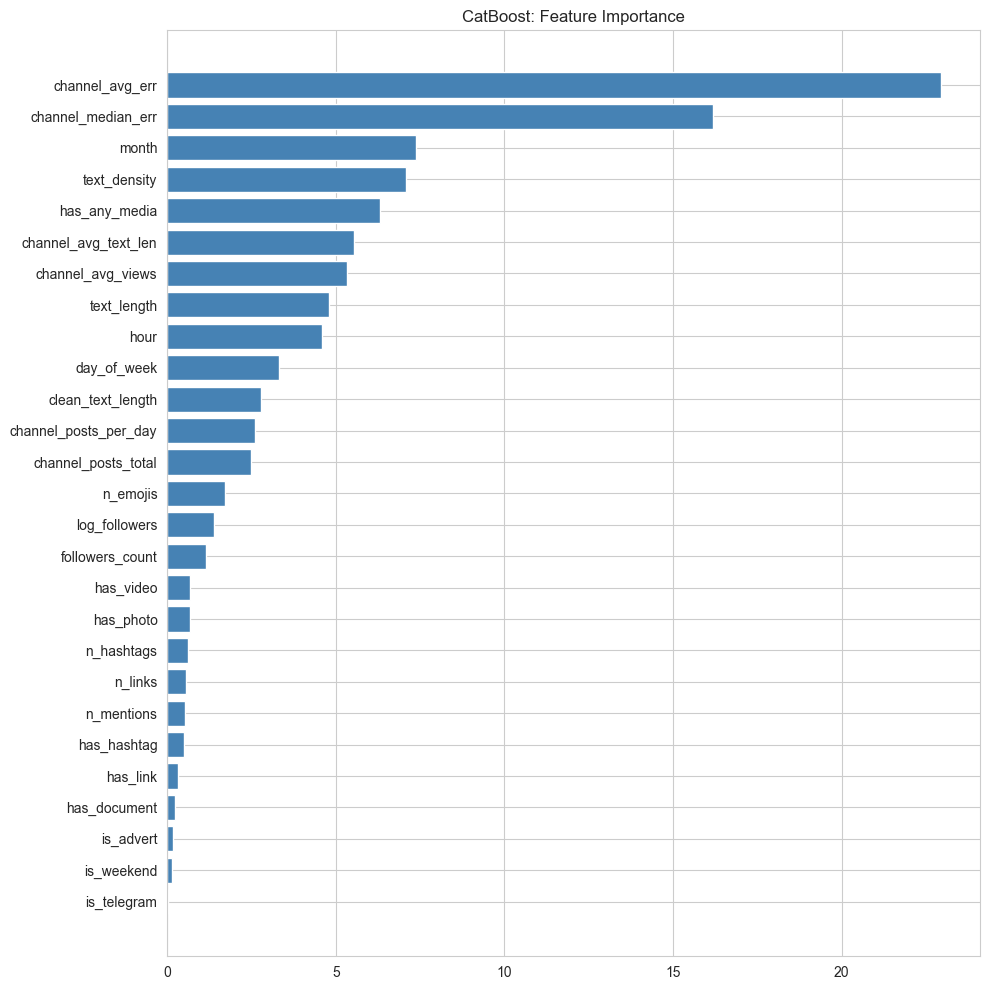


Топ-15:
              feature  importance
      channel_avg_err   22.958466
   channel_median_err   16.178365
                month    7.378698
         text_density    7.089519
        has_any_media    6.317620
 channel_avg_text_len    5.549579
    channel_avg_views    5.328741
          text_length    4.784715
                 hour    4.585183
          day_of_week    3.310671
    clean_text_length    2.791151
channel_posts_per_day    2.593131
  channel_posts_total    2.480686
             n_emojis    1.717322
        log_followers    1.391883


In [16]:
imp = pd.DataFrame({'feature':FEATURES,'importance':cb_final.feature_importances_}).sort_values('importance',ascending=True)
fig, ax = plt.subplots(figsize=(10,10))
ax.barh(imp['feature'], imp['importance'], color='steelblue')
ax.set_title('CatBoost: Feature Importance')
plt.tight_layout(); plt.show()
print('\nТоп-15:')
print(imp.tail(15)[::-1].to_string(index=False))

## 6. Residual Plot

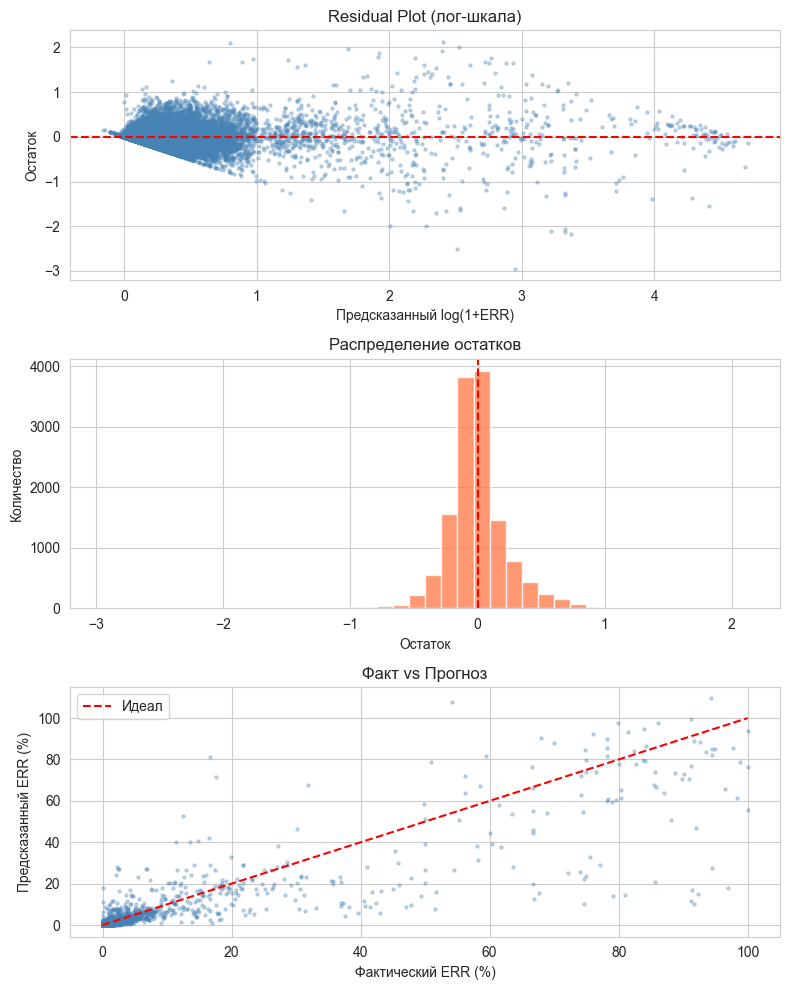

MAE: 0.65% | MedAE: 0.14% | Std: 3.45%


In [39]:
res = y_test_log - y_pred_cb
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

axes[0].scatter(y_pred_cb, res, alpha=0.3, s=5, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Предсказанный log(1+ERR)"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Residual Plot (лог-шкала)")

axes[1].hist(res, bins=40, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_xlabel("Остаток"); axes[1].set_ylabel("Количество")
axes[1].set_title("Распределение остатков")

yte, ype = np.expm1(y_test_log), np.expm1(y_pred_cb)
axes[2].scatter(yte, ype, alpha=0.3, s=5, color="steelblue")
axes[2].plot([0, yte.max()], [0, yte.max()], "r--", label="Идеал")
axes[2].set_xlabel("Фактический ERR (%)"); axes[2].set_ylabel("Предсказанный ERR (%)")
axes[2].set_title("Факт vs Прогноз")
axes[2].legend()
plt.tight_layout()
plt.show()

print(f"MAE: {mean_absolute_error(yte,ype):.2f}% | MedAE: {np.median(np.abs(yte-ype)):.2f}% | Std: {np.std(yte-ype):.2f}%")


## 7. 5-Fold CV

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=RND)
cv_r2, cv_mae, cv_rmse = [], [], []
for fold, (ti, vi) in enumerate(kf.split(X),1):
    m = CatBoostRegressor(**best_params, cat_features=cat_f, random_seed=RND, verbose=False)
    m.fit(X.iloc[ti], y_log.iloc[ti])
    yp = m.predict(X.iloc[vi])
    cv_r2.append(r2_score(y_log.iloc[vi],yp)); cv_mae.append(mean_absolute_error(y_log.iloc[vi],yp))
    cv_rmse.append(np.sqrt(mean_squared_error(y_log.iloc[vi],yp)))
    print(f'  Fold {fold}: R2={cv_r2[-1]:.4f}, MAE={cv_mae[-1]:.4f}, RMSE={cv_rmse[-1]:.4f}')
print(f'\nCV R2: {np.mean(cv_r2):.4f} +/- {np.std(cv_r2):.4f}')
print(f'CV MAE: {np.mean(cv_mae):.4f} +/- {np.std(cv_mae):.4f}')

  Fold 1: R2=0.8209, MAE=0.1661, RMSE=0.2556
  Fold 2: R2=0.8236, MAE=0.1673, RMSE=0.2608
  Fold 3: R2=0.8323, MAE=0.1647, RMSE=0.2535
  Fold 4: R2=0.8174, MAE=0.1652, RMSE=0.2579
  Fold 5: R2=0.8169, MAE=0.1655, RMSE=0.2550

CV R2: 0.8222 +/- 0.0056
CV MAE: 0.1658 +/- 0.0009


## 8. Сохранение модели

In [19]:
cb_final.save_model('../data/processed/catboost_err_model.cbm')
import json
meta = {'features':FEATURES,'cat_features':cat_f,'best_params':best_params,
        'metrics':{'R2':round(r2_score(y_test_log,y_pred_cb),4),'MAE_ERR%':round(mean_absolute_error(np.expm1(y_test_log),np.expm1(y_pred_cb)),2)}}
with open('../data/processed/model_meta.json','w',encoding='utf-8') as f: json.dump(meta,f,indent=2,ensure_ascii=False)
print('Сохранено: catboost_err_model.cbm + model_meta.json')

Сохранено: catboost_err_model.cbm + model_meta.json


## 9. Финальная таблица

In [23]:
df_f = pd.DataFrame(results).set_index('Model')
print('='*50)
print('ИТОГОВАЯ ТАБЛИЦА МЕТРИК')
print('='*50)
print(df_f[['R2','MAE_ERR%','RMSE_ERR%']].round(4).to_string())
best = df_f['R2'].idxmax()
b = df_f.loc[best]
print(f'\nЛучшая: {best} | R2={b["R2"]:.4f} | MAE={b["MAE_ERR%"]:.2f}% ERR')

ИТОГОВАЯ ТАБЛИЦА МЕТРИК
                      R2  MAE_ERR%  RMSE_ERR%
Model                                        
Mean Baseline    -0.0000    1.3906     7.3735
LinearRegression  0.5646    1.4676    11.7758
RandomForest      0.8159    0.6354     3.3580
CatBoost (base)   0.8082    0.6709     3.5207
CatBoost (tuned)  0.8190    0.6461     3.4571

Лучшая: CatBoost (tuned) | R2=0.8190 | MAE=0.65% ERR


## 10. Проверка модели на конкретном блогере

In [79]:
CHANNEL = "@evelone192gg"   # <-- вставь любой из списка
ch_mask = df["channel_username"] == CHANNEL
X_ch = X[ch_mask]
y_ch = np.expm1(y_log[ch_mask])
y_ch_pred = np.expm1(cb_final.predict(X_ch))

print(f"Канал: {CHANNEL}")
print(f"  Постов: {len(y_ch)}")
print(f"  ERR факт:     mean={y_ch.mean():.2f}%, median={np.median(y_ch):.2f}%")
print(f"  ERR прогноз:  mean={y_ch_pred.mean():.2f}%, median={np.median(y_ch_pred):.2f}%")
print(f"  MAE: {mean_absolute_error(y_ch, y_ch_pred):.2f}% | R²: {r2_score(y_ch, y_ch_pred):.3f}")


Канал: @evelone192gg
  Постов: 178
  ERR факт:     mean=0.14%, median=0.07%
  ERR прогноз:  mean=0.15%, median=0.14%
  MAE: 0.10% | R²: 0.333


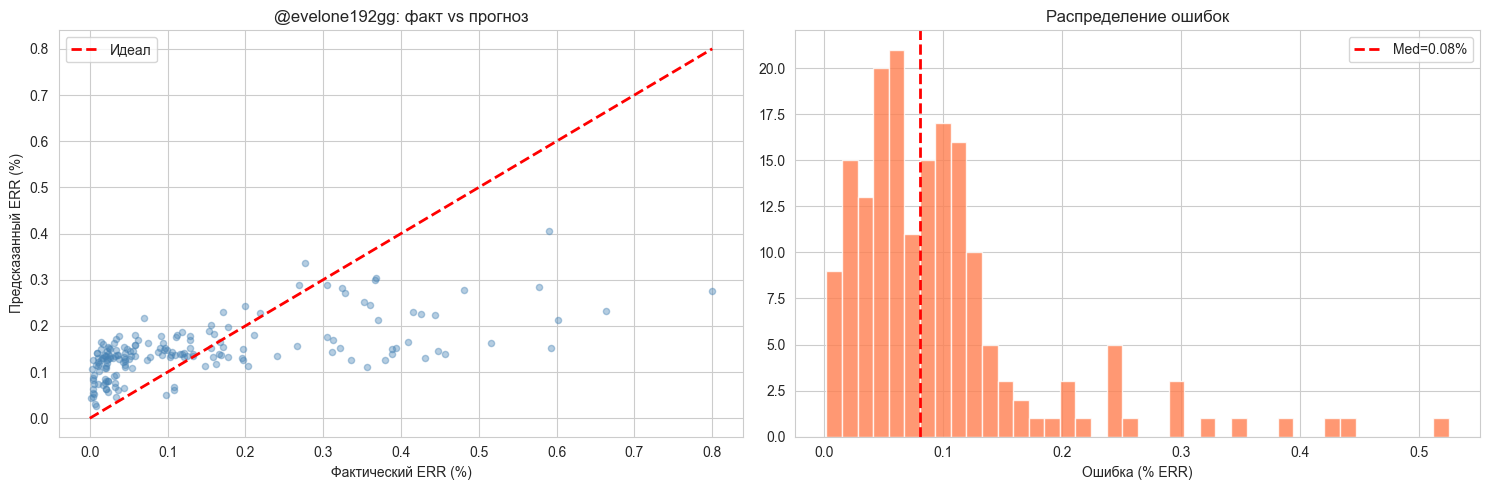

In [80]:
# Факт vs Прогноз
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(y_ch, y_ch_pred, alpha=0.4, s=20, color="steelblue")
axes[0].plot([0, y_ch.max()], [0, y_ch.max()], "r--", lw=2, label="Идеал")
axes[0].set_xlabel("Фактический ERR (%)")
axes[0].set_ylabel("Предсказанный ERR (%)")
axes[0].set_title(f"{CHANNEL}: факт vs прогноз")
axes[0].legend()

# Распределение ошибок
errors = (y_ch - y_ch_pred).abs()
axes[1].hist(errors, bins=40, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(errors.median(), color="red", lw=2, linestyle="--", label=f"Med={errors.median():.2f}%")
axes[1].set_xlabel("Ошибка (% ERR)")
axes[1].set_title("Распределение ошибок")
axes[1].legend()
plt.tight_layout()
plt.show()


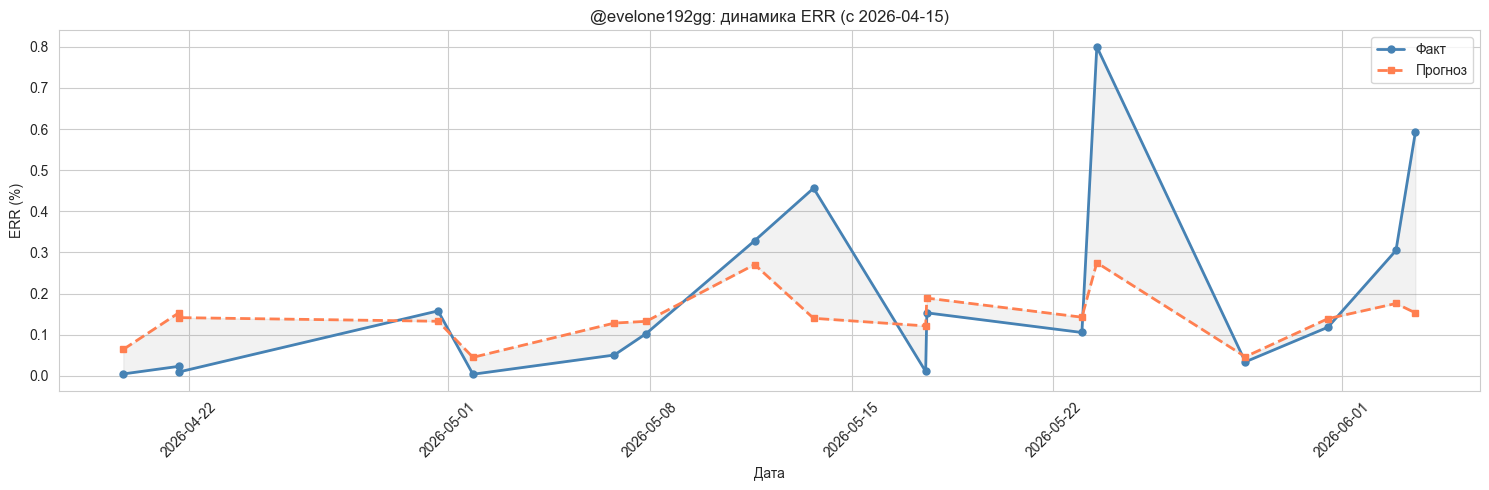

Постов на графике: 17
  ERR факт: mean=0.19%, median=0.11%
  ERR прогноз: mean=0.14%, median=0.14%
  MAE: 0.13%


In [81]:
# Динамика ERR по времени (даты уже в df из секции 1)
ch_data = df[ch_mask].copy()
ch_data["ERR_pred"] = y_ch_pred
ch_data["ERR_fact"] = y_ch.values

# Фильтр по дате
START = "2026-04-15"   # <-- измени дату
ch_data = ch_data[ch_data["published_at"] >= START].sort_values("published_at")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ch_data["published_at"], ch_data["ERR_fact"], "o-", color="steelblue", markersize=5, lw=2, label="Факт")
ax.plot(ch_data["published_at"], ch_data["ERR_pred"], "s--", color="coral", markersize=5, lw=2, label="Прогноз")
ax.fill_between(ch_data["published_at"], ch_data["ERR_fact"], ch_data["ERR_pred"], alpha=0.1, color="gray")
ax.set_xlabel("Дата"); ax.set_ylabel("ERR (%)")
ax.set_title(f"{CHANNEL}: динамика ERR (с {START})")
ax.legend(); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(f"Постов на графике: {len(ch_data)}")
print(f"  ERR факт: mean={ch_data["ERR_fact"].mean():.2f}%, median={ch_data["ERR_fact"].median():.2f}%")
print(f"  ERR прогноз: mean={ch_data["ERR_pred"].mean():.2f}%, median={ch_data["ERR_pred"].median():.2f}%")
print(f"  MAE: {mean_absolute_error(ch_data["ERR_fact"], ch_data["ERR_pred"]):.2f}%")


## 12. Прогноз ER для конкретного канала


In [82]:
import datetime
CH = "@evelone192gg"   # <-- enter any channel from the dataset

ch_data = df[df["channel_username"] == CH]
if len(ch_data) == 0:
    print(f"Channel {CH} not found in dataset")
else:
    # Auto-detect typical post params for this channel
    txt = int(ch_data["text_length"].median())
    h = int(ch_data["n_hashtags"].median()) if "n_hashtags" in ch_data.columns else 2
    l = int(ch_data["n_links"].median()) if "n_links" in ch_data.columns else 1
    e = int(ch_data["n_emojis"].median()) if "n_emojis" in ch_data.columns else 1
    ph = ch_data["has_photo"].mean() > 0.5 if "has_photo" in ch_data.columns else True
    vid = ch_data["has_video"].mean() > 0.3 if "has_video" in ch_data.columns else False
    f = ch_data["followers_count"].iloc[0]
    hist_err = ch_data["channel_avg_err"].iloc[0] if "channel_avg_err" in ch_data.columns else ch_data["ERR"].mean()
    today = datetime.date.today()
    print(f"Channel: {CH}")
    print(f"  Followers: {f:,.0f}  |  Historical avg ERR: {hist_err:.2f}%")
    print(f"  Typical post: {txt} chars, {h} hashtags, {l} links, {e} emoji, photo={ph}")
    print()
    print(f"{"":20s} {"Date":>12s} {"Dow":>5s} {"ER (ad) %":>10s}")
    print("-" * 55)
    for days in [0, 7, 30]:
        d = today + datetime.timedelta(days=days)
        dows = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
        dow = d.weekday()
        er = predict_for_channel(CH, txt, h, l, e, ph, vid,
                                has_link=(l>0), has_hashtag=(h>0),
                                is_advert=True, hour=18, day_of_week=dow, month=d.month)
        label = "Today" if days == 0 else f"+{days} days"
        print(f"  {label:20s} {d.strftime("%d.%m.%Y"):>12s} {dows[dow]:>5s} {er:>9.2f}%")


Channel: @evelone192gg
  Followers: 1,088,624  |  Historical avg ERR: 0.14%
  Typical post: 81 chars, 0 hashtags, 0 links, 1 emoji, photo=True

                             Date   Dow  ER (ad) %
-------------------------------------------------------
  Today                  08.06.2026   Mon      0.10%
  +7 days                15.06.2026   Mon      0.10%
  +30 days               08.07.2026   Wed      0.11%
